In [51]:
import matplotlib.pyplot as plt
from functools import reduce
from functools import partial
import sys
import os
# from google.colab import drive
# drive.mount('/content/drive')
import h5py
import numpy as np
from timeit import default_timer
import operator
from datetime import date
# !pip install pydmd
# from pydmd import OptDMD, DMD
from scipy.linalg import norm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from pathlib import Path

This file contains scripts that effectively recreate the existing plots in the arXiv paper.

Ok, this shows what files there are... Should be 3 per speed for each model

In [52]:
# which runs to load, newest per model unless RUN_SELECT is set
speed = "5Hz_200fps"

OUTPUT_ROOT = Path("./outputs")

# label shown in plots  ->  outputs/<subdirectory>
MODELS = {
    "Baseline (UNet)": "UNet",
    "UNet + PITA":     "UNet+PITA",
    "UNet + adv-NO":   "UNet+advNO",
}

# part of a filename to pick a specific run, None = most recent
RUN_SELECT = {
    "Baseline (UNet)": None,
    "UNet + PITA":     None,
    "UNet + adv-NO":   None,
}

# plot styles
MODEL_STYLE = {
    "Baseline (UNet)": dict(color="C0", marker="o", ls="--"),
    "UNet + PITA":     dict(color="C1", marker="s", ls="--"),
    "UNet + adv-NO":   dict(color="C2", marker="^", ls="-"),
}
TRUTH_STYLE = dict(color="black", ls="-", lw=2.2)

# old output folder
LEGACY_DIRS = [Path("./UNet Output")]
LEGACY_TAGS = {"UNet": "BASELINE_NO_PITA", "UNet+PITA": "BASELINE_WITH_PITA",
               "UNet+advNO": "BASELINE_ADV_NO"}


def list_runs(label):
    subdir = MODELS[label]
    files = sorted((OUTPUT_ROOT / subdir).glob(f"*{speed}*.h5"))
    if not files:
        tag = LEGACY_TAGS.get(subdir, subdir)
        for d in LEGACY_DIRS:
            files += sorted(d.glob(f"*{speed}*{tag}*.h5"))
    return files


def find_run(label):
    files = list_runs(label)
    sel = (RUN_SELECT.get(label) or "").strip()
    if sel:
        files = [f for f in files if sel in f.name]
        if not files:
            avail = "\n  ".join(f.name for f in list_runs(label)) or "(none)"
            raise FileNotFoundError(
                f"{label}: no run matching RUN_SELECT {sel!r} in "
                f"outputs/{MODELS[label]}/.  Available:\n  {avail}")
    if not files:
        raise FileNotFoundError(
            f"{label}: no runs found in outputs/{MODELS[label]}/. "
            f"Run the training + save cells for this model first.")
    h5 = files[-1]
    pt = h5.with_suffix(".pt")
    return h5, (pt if pt.exists() else None)


def show_available():
    print(f"{'model':<18}  {'runs':>4}  selected")
    print("=" * 78)
    for label in MODELS:
        available = list_runs(label)
        try:
            h5, _ = find_run(label)
            pin = f"  [pinned: {RUN_SELECT[label]}]" if RUN_SELECT.get(label) else ""
            print(f"{label:<18}  {len(available):>4}  {h5.name}{pin}")
        except FileNotFoundError as e:
            print(f"{label:<18}  {len(available):>4}  !! {str(e).splitlines()[0]}")
    print("=" * 78)

show_available()

model               runs  selected
Baseline (UNet)        4  20260907-211749_UNet_200epoch_bs16_5Hz_200fps_BASELINE_NO_PITA.h5
UNet + PITA            3  20260907-211757_UNet+PITA_200epoch_bs16_5Hz_200fps_BASELINE_WITH_PITA.h5
UNet + adv-NO          3  20260907-211805_UNet+advNO_200epoch_bs16_5Hz_200fps_BASELINE_ADV_NO.h5


Ok, here's some functions to make loading data easier

In [53]:
def load_run(label):
    # load a run and un-normalize, arrays are [C, B, H, W, T+1]
    h5, pt = find_run(label)
    with h5py.File(h5, "r") as f:
        a, p = f["u_actual"][:], f["u_pred"][:]
        ux_m, ux_s = f["u_x_mean"][()], f["u_x_std"][()]
        uy_m, uy_s = f["u_y_mean"][()], f["u_y_std"][()]
        meta = dict(f.attrs)
        losses = (f["train_losses"][:], f["test_losses"][:])
    assert a.shape[0] == 2 and p.shape[0] == 2, "expected [C=2, B, H, W, T+1]"
    a[0] = a[0] * ux_s + ux_m;  a[1] = a[1] * uy_s + uy_m
    p[0] = p[0] * ux_s + ux_m;  p[1] = p[1] * uy_s + uy_m
    return dict(label=label, h5=h5, pt=pt, act=a, pred=p, meta=meta, losses=losses,
                stats=dict(u_x_mean=ux_m, u_x_std=ux_s, u_y_mean=uy_m, u_y_std=uy_s))


def get_u_diff_norm(u_act, u_pred, num_steps=10):
    u_diff = []
    for i in range(num_steps):
        u_diff.append(np.linalg.norm(u_act[..., i+1] - u_pred[..., i+1]) / np.linalg.norm(u_act[..., i+1]))
    return u_diff

Ok, let's load in some data to make some sample plots

In [54]:
_r = load_run("Baseline (UNet)")
unet_act, unet_pred = _r["act"], _r["pred"]
print(f"loaded {_r['h5'].name}  ->  {unet_act.shape}  [C, B, H, W, T+1]")

loaded 20260907-211749_UNet_200epoch_bs16_5Hz_200fps_BASELINE_NO_PITA.h5  ->  (2, 48, 133, 89, 11)  [C, B, H, W, T+1]


Let's start with plotting flow-fields themselves

Ok, the below plot can be used to recreate figure 5 in the paper

(2, 48, 133, 89, 11)
0.2719411


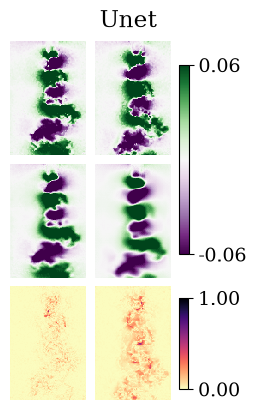

In [55]:
def plot_flow(ffield, cmap="PRGn", vmin=None, vmax=None):
    if vmin is None:
        vmin = np.round(np.min(ffield), decimals=2) - 0.01
    if vmax is None:
        vmax = np.round(np.max(ffield), decimals=2) + 0.01
    im = plt.imshow(ffield, aspect="equal", interpolation="none", cmap=cmap, vmin=vmin, vmax=vmax)
    ax = plt.gca()
    ax.set_aspect("equal")
    ax.set_axis_off()
    return im

def flowvis_comparison(act, act_u, pred, title):
    U = np.mean(act_u[:5, :40, :])
    print(U)

    vmin = -.06
    vmax = .06

    fig, axs = plt.subplots(3, 2, figsize=(4, 4), layout="compressed")

    plt.subplot(3,2,1)
    im = plot_flow(act[:, :, 1], vmin=vmin, vmax=vmax)
    plt.subplot(3,2,2)
    plot_flow(act[:, :, 10], vmin=vmin, vmax=vmax)
    plt.subplot(3,2,3)
    plot_flow(pred[:, :, 1], vmin=vmin, vmax=vmax)
    plt.subplot(3,2,4)
    plot_flow(pred[:, :, 10], vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(im, ax=axs[:2], shrink=0.8)
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels([f"{vmin:.2f}", f"{vmax:.2f}"])

    plt.subplot(3,2,5)
    im2 = plot_flow(np.abs(act[:, :, 1] - pred[:, :, 1]) / U, vmin=0, vmax=1, cmap="magma_r")
    plt.subplot(3,2,6)
    plot_flow(np.abs(act[:, :, 10] - pred[:, :, 10]) / U, vmin=0, vmax=1, cmap="magma_r")
    cbar2 = fig.colorbar(im2, ax=axs[-1], aspect=10, shrink=0.8)
    cbar2.set_ticks([0, 1])
    cbar2.set_ticklabels(["0.00", "1.00"])

    plt.suptitle(title)
    plt.show()
    plt.close()

# UNet only
print(unet_act.shape)
act = unet_act[1, 0, ...]
pred = unet_pred[1, 0, ...]

plt.rcParams['font.size'] = 14
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
flowvis_comparison(act, unet_act[0, 0, ...], pred, 'Unet')

# act = fno_act[1, 0, ...]; pred = fno_pred[1, 0, ...]
# flowvis_comparison(act, unet_act[0, 0, ...], pred, 'fno')
# act = dmd_act[1, 0, ...]; pred = dmd_pred[1, 0, ...]
# flowvis_comparison(act, unet_act[0, 0, ...], pred, 'dmd')
# act = cnn_act[1, 0, ...]; pred = cnn_pred[1, 0, ...]
# flowvis_comparison(act, unet_act[0, 0, ...], pred, 'cnn')

In [56]:
# def load_longer_data(model_type, speed="5Hz_200fps"):
#     u_actual = []
#     u_pred = []
#     with h5py.File(f'/content/drive/MyDrive/FNO/{model_type}_{speed}_longer.h5', 'r') as f:
#         u_actual.append(f["u_actual_1"][:])
#         u_pred.append(f["u_pred_1"][:])
#         u_actual.append(f["u_actual_2"][:])
#         u_pred.append(f["u_pred_2"][:])
#         u_actual.append(f["u_actual_3"][:])
#         u_pred.append(f["u_pred_3"][:])
# 
#     return np.stack(u_actual), np.stack(u_pred)
# 
# 
# unet_act, unet_pred = load_longer_data("UNet", "5Hz_200fps")
# fno_act, fno_pred = load_longer_data("FNO", "5Hz_200fps")
# cnn_act, cnn_pred = load_longer_data("CNN", "5Hz_200fps")
# dmd_act, dmd_pred = load_longer_data("DMD", "5Hz_200fps")

In [57]:
# def flowvis_comparison(act, act_u,pred,title):
# 
#     U = np.mean(act_u[:5, :40, :])
#     print(U)
# 
#     # plt.figure(figsize=(8, 8))
# 
#     vmin = -.06#np.min((np.round(np.min(act), decimals=2) - 0.01, np.round(np.min(pred), decimals=2) - 0.01))# -0.25
#     vmax = .06#np.max((np.round(np.max(act), decimals=2) + 0.01, np.round(np.max(pred), decimals=2) + 0.01))#0.55
# 
#     fig, axs = plt.subplots(3, 2, figsize=(4, 4), layout="compressed")
# 
# 
#     plt.subplot(3,2,1)
#     im = plot_flow(act[:, :, 1], vmin=vmin, vmax=vmax)
# 
#     plt.subplot(3,2,2)
#     plot_flow(act[:, :, 10], vmin=vmin, vmax=vmax)
#     plt.subplot(3,2,3)
#     plot_flow(pred[:, :, 1], vmin=vmin, vmax=vmax)
#     plt.subplot(3,2,4)
#     plot_flow(pred[:, :, 10], vmin=vmin, vmax=vmax)
#     cbar = fig.colorbar(im, ax=axs[:2], shrink=0.8)
#     cbar.set_ticks([vmin, vmax])
#     cbar.set_ticklabels([f"{vmin:.2f}", f"{vmax:.2f}"])
# 
#     plt.subplot(3,2,5)
#     im2 = plot_flow(np.abs(act[:, :, 1] - pred[:, :, 1]) / U, vmin=0, vmax=1, cmap="BuPu")
#     plt.subplot(3,2,6)
#     plot_flow(np.abs(act[:, :, 10] - pred[:, :, 10]) / U, vmin=0, vmax=1, cmap="BuPu")
#     cbar2 = fig.colorbar(im2, ax=axs[-1], aspect=10, shrink=0.8)
#     cbar2.set_ticks([0, 1])
#     cbar2.set_ticklabels(["0.00", "1.00"])
#     # cbar2.set_label(r'\frac{|u_i^* - u_i|}{U}', labelpad=10, rotation=0)
#     # plt.tight_layout()
# 
#     plt.suptitle(title)
#     plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig3_"+title+".svg"))
#     plt.show()
#     plt.close()
# 
# 
# print(dmd_act.shape)
# # U net
# # This should give me an 89 x 133 x 11 array
# act = unet_act[0,1,0,:,:,:]
# pred = unet_pred[0,1,0,:,:,:]
# flowvis_comparison(act, unet_act[0,0,0,:,:,:],pred,'Unet')
# 
# # FNO net
# # This should give me an 89 x 133 x 11 array
# act = fno_act[0,1,0,:,:,:]
# pred = fno_pred[0,1,0,:,:,:]
# flowvis_comparison(act, fno_act[0,0,0,:,:,:],pred,'FNO')
# 
# # cnn
# # This should give me an 89 x 133 x 11 array
# act = cnn_act[0,1,0,:,:,:]
# pred = cnn_pred[0,1,0,:,:,:]
# flowvis_comparison(act, cnn_act[0,0,0,:,:,:],pred,'CNN')
# 
# # dmd
# # This should give me an 89 x 133 x 11 array
# act = dmd_act[0,1,:,:,:,0]
# pred = dmd_pred[0,1,:,:,:,0]
# flowvis_comparison(act, dmd_act[0,0,:,:,:,0],pred,'DMD')
# 

Ok, let's work on getting plots for themean absolute error (i.e. Figure 6)

In [58]:
# # u_act = unet_actual[0]
# # u_pred = unet_pred[0]
# 
# plt.rcParams['font.size'] = 14  # Set default font size to 14
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
# # plt.rcParams['text.usetex'] = True
# 
# # print(np.shape(u_act))
# # print(type(u_act))
# 
# 
# def plot_flow(ffield, cmap="turbo", vmin=None, vmax=None):
#     if vmin is None:
#         vmin = np.round(np.min(ffield), decimals=2) - 0.01
#     if vmax is None:
#         vmax = np.round(np.max(ffield), decimals=2) + 0.01
#     im = plt.imshow(ffield, aspect="equal", interpolation="none", cmap=cmap, vmin=vmin, vmax=vmax)
#     ax = plt.gca()
#     ax.set_aspect("equal")
#     ax.set_axis_off()
#     # plt.tight_layout()
#     return im
# 
# def mean_error_plots(act, pred, labels=[], suptitle=""):
#     fig, axs = plt.subplots(2, 4, figsize=(8, 8), layout="compressed")
# 
#     # Get maximum error for normalizing
#     vmin, vmax = 0, 0.15
#     for i in range(len(act)):
#       print(i)
#       cur_act = act[i]
#       difference = pred[i]-act[i]
#       U = np.mean(cur_act[:,:,:5,:40,-1],axis=(1,2,3))[0]
#       err = np.mean(difference,axis=1)/U
#       vmax = np.max([np.max((np.round(np.max(err), decimals=2) + 0.01, np.round(np.max(err), decimals=2) + 0.01)),vmax])
# 
#     # Generate plots
#     for i in range(len(act)):
#       cur_act = act[i]
#       difference = np.abs(pred[i]-act[i])
#       U = np.mean(cur_act[:,:,:5,:40,-1],axis=(1,2,3))[0]
#       print(difference.shape)
#       print(cur_act.shape)
#       err = np.mean(difference,axis=(1,4))/U
#       plt.subplot(2,4,i+1)
#       im = plot_flow(err[0,:, :], vmin=vmin, vmax=vmax, cmap="magma_r")
#       if labels:
#         plt.title(labels[i])
#       plt.subplot(2,4,i+5)
#       plot_flow(err[1,:, :], vmin=vmin, vmax=vmax, cmap="magma_r")
# 
#     if suptitle:
#       fig.suptitle(suptitle)
#     # Create colorbar
#     cbar = fig.colorbar(im, ax=axs[:2, :], shrink=0.8)
#     # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig8_comparison.svg"))
#     # plt.show()
# 
# mean_error_plots([unet_act, fno_act, cnn_act, dmd_act],
#                  [unet_pred, fno_pred, cnn_pred, dmd_pred],
#                  ["UNet", "FNO", "CNN", "DMD"],
#                  suptitle=f"{speed}")

Ok now I want to plot error as a function of timestep

In [59]:
# unet_diff = get_u_diff_norm(unet_act, unet_pred)
# fno_diff = get_u_diff_norm(fno_act, fno_pred)
# cnn_diff = get_u_diff_norm(cnn_act, cnn_pred)
# dmd_diff = get_u_diff_norm(dmd_act, dmd_pred)

In [60]:
# 
# # plt.plot(unet_diff,color='#0372B2',marker="o")
# # plt.plot(fno_diff,color='#CC79A6',marker="s")
# # plt.plot(cnn_diff,color='#009F73',marker="D")
# # plt.plot(dmd_diff,color='#D55D03',marker="v")
# plt.plot(unet_diff,color=(148/255,203/255,236/255),marker="o")
# plt.plot(fno_diff,color=(93/255,168/255,153/255),marker="s")
# plt.plot(cnn_diff,color=(194/255,106/255,119/255),marker="D")
# plt.plot(dmd_diff,color=(220/255,205/255,125/255),marker="v")
# plt.legend(["UNet", "FNO", "CNN", "DMD"])
# plt.title(f"{speed}")
# plt.grid(True)
# plt.xlabel("timestep")
# plt.ylabel("normalized error")
# # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig5_10timesteps.svg"))

Ok, now we can look at a single model across Reynolds numbers

In [61]:
# def get_u_diff_norm_all(u_act, u_pred, num_steps=10):
#     """
#       Get the normalized difference between the prediction and actual data.
#     """
#     u_diff = []
#     for i in range(num_steps):
#         u_diff.append(np.linalg.norm(u_act[..., i+1] - u_pred[..., i+1]) / np.linalg.norm(u_act[..., i+1]))
# 
#     return u_diff

In [62]:
# unet_diff = []
# 
# model_type, speed = "UNet", "2Hz_80fps"
# unet_act_2, unet_pred_2 = load_all_data(model_type, speed)
# unet_diff.append(get_u_diff_norm_all(unet_act_2, unet_pred_2))
# del unet_act_2, unet_pred_2
# 
# speed = "5Hz_200fps"
# unet_act_5, unet_pred_5 = load_all_data(model_type, speed)
# unet_diff.append(get_u_diff_norm_all(unet_act_5, unet_pred_5))
# del unet_act_5, unet_pred_5
# 
# speed = "7Hz_280fps"
# unet_act_7, unet_pred_7 = load_all_data(model_type, speed)
# unet_diff.append(get_u_diff_norm_all(unet_act_7, unet_pred_7))
# del unet_act_7, unet_pred_7
# 
# speed = "10Hz_400fps"
# unet_act_10, unet_pred_10 = load_all_data(model_type, speed)
# unet_diff.append(get_u_diff_norm_all(unet_act_10, unet_pred_10))
# del unet_act_10, unet_pred_10
# 
# speed = "15Hz_600fps"
# unet_act_15, unet_pred_15 = load_all_data(model_type, speed)
# unet_diff.append(get_u_diff_norm_all(unet_act_15, unet_pred_15))
# del unet_act_15, unet_pred_15
# 
# speed = "20Hz_800fps"
# unet_act_20, unet_pred_20 = load_all_data(model_type, speed)
# unet_diff.append(get_u_diff_norm_all(unet_act_20, unet_pred_20))
# del unet_act_20, unet_pred_20
# 
# speed = "25Hz_1000fps"
# unet_act_25, unet_pred_25 = load_all_data(model_type, speed)
# unet_diff.append(get_u_diff_norm_all(unet_act_25, unet_pred_25))
# del unet_act_25, unet_pred_25

In [63]:
# unet_diff = []

# unet_diff.append(get_u_diff_norm_all(unet_act_2, unet_pred_2))
# print("2Hz done")
# unet_diff.append(get_u_diff_norm_all(unet_act_5, unet_pred_5))
# unet_diff.append(get_u_diff_norm_all(unet_act_7, unet_pred_7))
# unet_diff.append(get_u_diff_norm_all(unet_act_10, unet_pred_10))
# unet_diff.append(get_u_diff_norm_all(unet_act_15, unet_pred_15))
# unet_diff.append(get_u_diff_norm_all(unet_act_20, unet_pred_20))
# unet_diff.append(get_u_diff_norm_all(unet_act_25, unet_pred_25))

In [64]:
# unet_diff = np.stack(unet_diff)

In [65]:
# unet_diff.shape

Plotting it. Figure 4b equivalent

In [66]:
# Re = [240, 650, 900, 1300, 1900, 2500, 3100]
# colorDict = {'UNet': '#0372B2','FNO':'#CC79A6','CNN':'#009F73','DMD':'#D55D03'}
# 
# cmap=plt.colormaps['twilight_shifted']
# 
# for i in range(len(unet_diff[0, :])):
#   plt.plot(Re, unet_diff[:, i], label=f"{i+1}",color=cmap(.4*(0.1*i)),marker=".")#colorDict['UNet'],alpha=0.1*(10-i))
# 
# plt.legend()
# plt.grid(True)
# plt.xlabel("Reynolds Number")
# plt.ylabel("normalized error")
# plt.title(f"{model_type}")
# plt.ylim([0,.1])
# # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig7b_unet.svg"))
# plt.show()

Now per-reynolds number across timesteps. Figure 4a equivalent.

In [67]:
# Re = [240, 650, 900, 1300, 1900, 2500, 3100]
# 
# cmap=plt.colormaps['BuPu']
# markers=['.','^','o','x','d','v','s']
# 
# for i in range(len(unet_diff[:, 0])):
#   plt.plot(np.arange(1, 11), unet_diff[i, :], label=f"{Re[i]}",color=cmap(0.3+0.1*i),marker=markers[i])
# 
# plt.legend()
# plt.grid(True)
# plt.xlabel("t*")
# plt.ylabel("normalized error")
# plt.title(f"{model_type}")
# plt.ylim([0,.1])
# # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig7a_unet.svg"))
# plt.show()

In [68]:
# # Mean error plots for unet
# model_type, speed = "UNet", "2Hz_80fps"
# unet_act_2, unet_pred_2 = load_all_data(model_type, speed)
# 
# speed = "10Hz_400fps"
# unet_act_10, unet_pred_10 = load_all_data(model_type, speed)
# 
# speed = "25Hz_1000fps"
# unet_act_25, unet_pred_25 = load_all_data(model_type, speed)

In [69]:
# 
# plt.rcParams['font.size'] = 14  # Set default font size to 14
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
# 
# def plot_flow(ffield, cmap="turbo", vmin=None, vmax=None):
#     if vmin is None:
#         vmin = np.round(np.min(ffield), decimals=2) - 0.01
#     if vmax is None:
#         vmax = np.round(np.max(ffield), decimals=2) + 0.01
#     im = plt.imshow(ffield, aspect="equal", interpolation="none", cmap=cmap, vmin=vmin, vmax=vmax)
#     ax = plt.gca()
#     ax.set_aspect("equal")
#     ax.set_axis_off()
#     # plt.tight_layout()
#     return im
# 
# def mean_error_plots_Re(act, pred, labels=[], suptitle=""):
#     fig, axs = plt.subplots(2, 3, figsize=(8, 8), layout="compressed")
# 
#     # Get maximum error for normalizing
#     vmin, vmax = 0, 0.15
#     for i in range(len(act)):
#       print(i)
#       cur_act = act[i]
#       difference = pred[i]-act[i]
#       U = np.mean(cur_act[:,:,:5,:40,-1],axis=(1,2,3))[0]
#       err = np.mean(difference,axis=1)/U
#       vmax = np.max([np.max((np.round(np.max(err), decimals=2) + 0.01, np.round(np.max(err), decimals=2) + 0.01)),vmax])
# 
#     # Generate plots
#     for i in range(len(act)):
#       cur_act = act[i]
#       difference = np.abs(pred[i]-act[i])
#       U = np.mean(cur_act[:,:,:5,:40,-1],axis=(1,2,3))[0]
#       print(difference.shape)
#       print(cur_act.shape)
#       err = np.mean(difference,axis=(1,4))/U
#       plt.subplot(2,3,i+1)
#       im = plot_flow(err[0,:, :], vmin=vmin, vmax=vmax, cmap='BuPu')#"magma_r")
#       if labels:
#         plt.title(labels[i])
#       plt.subplot(2,3,i+4)
#       plot_flow(err[1,:, :], vmin=vmin, vmax=vmax, cmap='BuPu')#"magma_r")
# 
#     if suptitle:
#       fig.suptitle(suptitle)
#     # Create colorbar
#     cbar = fig.colorbar(im, ax=axs[:2, :], shrink=0.8)
#     # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig8_"+suptitle+".svg"))
#     plt.show()
# 
# def mean_error_plots_Re_diverging(act, pred, labels=[], suptitle=""):
#     fig, axs = plt.subplots(2, 3, figsize=(8, 8), layout="compressed")
# 
#     # Get maximum error for normalizing
#     vmin, vmax = 0, 0.
#     for i in range(len(act)):
#       print(i)
#       cur_act = act[i]
#       difference = pred[i]-act[i]
#       U = np.mean(cur_act[:,:,:5,:40,-1],axis=(1,2,3))[0]
#       err = np.mean(difference,axis=1)/U
#       vmax = np.max([np.max(np.abs(err)),vmax])
# 
#     # Generate plots
#     for i in range(len(act)):
#       cur_act = act[i]
#       difference = pred[i]-act[i]
#       U = np.mean(cur_act[:,:,:5,:40,-1],axis=(1,2,3))[0]
#       print(difference.shape)
#       print(cur_act.shape)
#       err = np.mean(difference,axis=(1,4))/U
#       plt.subplot(2,3,i+1)
#       im = plot_flow(err[0,:, :], cmap='PRGn')#, vmin=-vmax, vmax=vmax, cmap='PRGn')#"magma_r")
#       if labels:
#         plt.title(labels[i])
#       plt.subplot(2,3,i+4)
#       plot_flow(err[1,:, :], cmap='PRGn')#, vmin=-vmax, vmax=vmax, cmap='PRGn')#"magma_r")
# 
#     if suptitle:
#       fig.suptitle(suptitle)
#     # Create colorbar
#     cbar = fig.colorbar(im, ax=axs[:2, :], shrink=0.8)
#     # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig8_diverging_"+suptitle+".svg"))
#     plt.show()
# 
# # mean_error_plots_Re([unet_act_2, unet_act_10, unet_act_25],
# #                  [unet_pred_2, unet_pred_10, unet_pred_25],
# #                  ["240", "1300", "3100"],
# #                  suptitle=model_type)
# 
# # mean_error_plots_Re_diverging([unet_act_2, unet_act_10, unet_act_25],
# #                  [unet_pred_2, unet_pred_10, unet_pred_25],
# #                  ["240", "1300", "3100"],
# #                  suptitle=model_type)

In [70]:
# models = ['DMD'] #'UNet','FNO','CNN',
# for model_type in models:
#     # Mean error plots for unet
#     speed = "2Hz_80fps"
#     act_2, pred_2 = load_all_data(model_type, speed)
# 
#     speed = "10Hz_400fps"
#     act_10, pred_10 = load_all_data(model_type, speed)
# 
#     speed = "25Hz_1000fps"
#     act_25, pred_25 = load_all_data(model_type, speed)
# 
#     mean_error_plots_Re([act_2, act_10, act_25],
#                  [pred_2, pred_10, pred_25],
#                  ["240", "1300", "3100"],
#                  suptitle=model_type)

In [71]:
# mean_error_plots_Re([act_2, act_10, act_25],
#                  [pred_2, pred_10, pred_25],
#                  ["240", "1300", "3100"],
#                  suptitle=model_type)

In [72]:
# with h5py.File(f'/content/drive/MyDrive/FNO/all_model_diff_summary.h5', 'r') as f:
#     unet_diff = f["unet_diff"][:]
#     fno_diff = f["fno_diff"][:]
#     cnn_diff = f["cnn_diff"][:]
#     dmd_diff = f["dmd_diff"][:]

In [73]:
# print(unet_diff.shape)
# Re = [230, 590, 830, 1180, 1780, 2370, 2920]
# t_steps = np.linspace(1,unet_diff.shape[1],unet_diff.shape[1])
# 
# # print(unet_diff)
# # print(np.ndarray.flatten(unet_diff))
# # print(np.ndarray.flatten(np.matlib.repmat(t_steps,len(Re),1)))
# # print(np.ndarray.flatten(np.array([[re]*len(t_steps) for re in Re])))
# 
# unet_df = pd.DataFrame.from_dict({'Re': np.ndarray.flatten(np.array([[re]*len(t_steps) for re in Re])), \
#            't step': np.ndarray.flatten(np.matlib.repmat(t_steps,len(Re),1)), \
#            'diff': np.ndarray.flatten(unet_diff), \
#            'model': ['unet']*len(np.ndarray.flatten(unet_diff))})
# 
# fno_df = pd.DataFrame.from_dict({'Re': np.ndarray.flatten(np.array([[re]*len(t_steps) for re in Re])), \
#            't step': np.ndarray.flatten(np.matlib.repmat(t_steps,len(Re),1)), \
#            'diff': np.ndarray.flatten(fno_diff), \
#            'model': ['fno']*len(np.ndarray.flatten(unet_diff))})
# 
# cnn_df = pd.DataFrame.from_dict({'Re': np.ndarray.flatten(np.array([[re]*len(t_steps) for re in Re])), \
#            't step': np.ndarray.flatten(np.matlib.repmat(t_steps,len(Re),1)), \
#            'diff': np.ndarray.flatten(cnn_diff), \
#            'model': ['cnn']*len(np.ndarray.flatten(unet_diff))})
# 
# dmd_df = pd.DataFrame.from_dict({'Re': np.ndarray.flatten(np.array([[re]*len(t_steps) for re in Re])), \
#            't step': np.ndarray.flatten(np.matlib.repmat(t_steps,len(Re),1)), \
#            'diff': np.ndarray.flatten(dmd_diff), \
#            'model': ['dmd']*len(np.ndarray.flatten(unet_diff))})
# 
# 
# diff_df = df_merged = pd.concat([unet_df, fno_df,cnn_df,dmd_df], ignore_index=True, sort=False)

In [74]:
# import seaborn as sns
# import pandas as pd

In [75]:
# fig, ax = plt.subplots(figsize=(8, 6))
# cmap=plt.colormaps['twilight_shifted']
# import matplotlib.colors as colors
# def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
#     new_cmap = colors.LinearSegmentedColormap.from_list(
#         'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
#         cmap(np.linspace(minval, maxval, n)))
#     return new_cmap
# 
# cmap = truncate_colormap(cmap, 0., 0.4)
# 
# markers_map = {}
# markers = ['.','^','o','X','d','v','s']
# for i,re in enumerate(Re):
#   markers_map[re] = markers[i]
# 
# # for i in range(len(unet_diff[0, :])):
# #   plt.plot(Re, unet_diff[:, i], label=f"{i+1}",color=cmap(.4*(0.1*i)),marker=".")#colorDict['UNet'],alpha=0.1*(10-i))
# 
# 
# sns.lineplot(data=unet_df, x="Re", y="diff", hue="t step",errorbar=None,\
#              palette = cmap,marker='o')
#              #ax=ax,errorbar=("pi", 100),err_style="bars",  err_kws={'linewidth': 0,'capsize': 10} )
# plt.ylim([0,0.1])
# plt.xlim([150,3000])
# plt.grid(True)
# # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig7b_sns.svg"))
# 
# plt.show()

In [76]:
# for data,model in zip([unet_df,fno_df,cnn_df,dmd_df],['unet','fno','cnn','dmd']):
#   cmap=plt.colormaps['twilight_shifted']
#   cmap = truncate_colormap(cmap, 0., 0.4)
#   fig, ax = plt.subplots(figsize=(8, 6))
#   sns.lineplot(data=data, x="Re", y="diff", hue="t step",errorbar=None,\
#               palette = cmap,marker='o')
#               #ax=ax,errorbar=("pi", 100),err_style="bars",  err_kws={'linewidth': 0,'capsize': 10} )
#   plt.ylim([0,0.13])
#   plt.xlim([150,3000])
#   plt.grid(True)
#   plt.title(model)
#   # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig7_supp_Re_"+model+".svg"))
# 
#   cmap=plt.colormaps['BuPu']
#   cmap = truncate_colormap(cmap, 0.3, 1.)
#   fig, ax = plt.subplots(figsize=(8, 6))
#   sns.lineplot(data=data, x="t step", y="diff", hue="Re", style="Re",errorbar=None,\
#               palette = cmap,markers=markers_map,dashes=False)
#               #ax=ax,errorbar=("pi", 100),err_style="bars",  err_kws={'linewidth': 0,'capsize': 10} )
#   plt.ylim([0,0.13])
#   plt.grid(True)
#   plt.title(model)
#   # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig7_supp_t_"+model+".svg"))
# plt.close('all')

In [77]:
# fig, ax = plt.subplots(figsize=(8, 6))
# cmap=plt.colormaps['BuPu']
# import matplotlib.colors as colors
# def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
#     new_cmap = colors.LinearSegmentedColormap.from_list(
#         'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
#         cmap(np.linspace(minval, maxval, n)))
#     return new_cmap
# 
# cmap = truncate_colormap(cmap, 0.3, 1.)
# 
# 
# sns.lineplot(data=unet_df, x="t step", y="diff", hue="Re", style="Re",errorbar=None,\
#              palette = cmap,markers=markers_map,dashes=False)
#              #ax=ax,errorbar=("pi", 100),err_style="bars",  err_kws={'linewidth': 0,'capsize': 10} )
# plt.ylim([0,0.1])
# plt.grid(True)
# # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig7a_sns.svg"))
# 
# plt.show()

In [78]:
# print(Re)
# print(markers_map)
# print(unet_df)

In [79]:
# # fig, ax = plt.subplots(figsize=(8, 6))
# # sns.lineplot(data=diff_df, x="Re", y="diff", hue="model",style="model",errorbar=None,\
# #              palette = ['#829ba0','#376243','#683332','#8f8027'],markers={'unet':'o','fno':'s','cnn':'D','dmd':'v'},\
# #              dashes=False)
# #              #ax=ax,errorbar=("pi", 100),err_style="bars",  err_kws={'linewidth': 0,'capsize': 10} )
# 
# fig, ax = plt.subplots(figsize=(8, 6))
# sns.lineplot(data=diff_df, x="Re", y="diff", hue="model",style="model",errorbar=None,\
#              palette = ['black','black','black','black'],markers={'unet':'o','fno':'s','cnn':'D','dmd':'v'})
#              #ax=ax,errorbar=("pi", 100),err_style="bars",  err_kws={'linewidth': 0,'capsize': 10} )
# plt.ylim([0,0.12])
# plt.grid(True)
# # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig4.svg"))
# 
# 
# plt.show()

In [80]:
# with h5py.File(f'/content/drive/MyDrive/FNO/all_model_long_diff_5Hz_200fps.h5', 'r') as f:
#     unet_diff = f["unet_diff"][:]
#     fno_diff = f["fno_diff"][:]
#     cnn_diff = f["cnn_diff"][:]
#     dmd_diff = f["dmd_diff"][:]
# 
# 
# plt.plot(range(1, 31), unet_diff,'k')
# plt.plot(range(1, 31), fno_diff,'k--')
# plt.plot(range(1, 31), cnn_diff,'k-.')
# plt.plot(range(1, 31), dmd_diff,'k:')
# plt.legend(["UNet", "FNO", "CNN", "DMD"])
# plt.grid(True)
# plt.xlim([0,31])
# plt.xlabel("timestep")
# plt.ylabel("normalized error")
# # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig5.svg"))

In [81]:
# import matplotlib.pyplot as plt
# import h5py
# # Note: the "la" and "lp" subscripts are SUPPOSED to stand for "laplacian actual"
# # and "laplacian predicted". However, there was a bug in the processing code I used
# # for these, so they came out backwards.
# with h5py.File('/content/drive/MyDrive/FNO/all_model_laplace.h5', 'r') as f:
#     unet_la_1 = f['unet_la_1'][:]
#     unet_lp_1 = f['unet_lp_1'][:]
#     unet_la_10 = f['unet_la_10'][:]
#     unet_lp_10 = f['unet_lp_10'][:]
# 
#     fno_la_1 = f['fno_la_1'][:]
#     fno_lp_1 = f['fno_lp_1'][:]
#     fno_la_10 = f['fno_la_10'][:]
#     fno_lp_10 = f['fno_lp_10'][:]
# 
#     cnn_la_1 = f['cnn_la_1'][:]
#     cnn_lp_1 = f['cnn_lp_1'][:]
#     cnn_la_10 = f['cnn_la_10'][:]
#     cnn_lp_10 = f['cnn_lp_10'][:]
# 
#     dmd_la_1 = f['dmd_la_1'][:]
#     dmd_lp_1 = f['dmd_lp_1'][:]
#     dmd_la_10 = f['dmd_la_10'][:]
#     dmd_lp_10 = f['dmd_lp_10'][:]
# 
# 
# 
# 
# def get_difference_normalized_laplacian(u_lp_1, u_la_1, u_lp_10, u_la_10):
#     # This is giving the difference between the prediction ("la") and actual ("lp")
#     # values, normalized by the actual ("lp")
#     u_dnl_1 = [(lp - la) / lp for lp, la in zip(u_lp_1, u_la_1)]
#     u_dnl_10 = [(lp - la) / lp for lp, la in zip(u_lp_10, u_la_10)]
#     return u_dnl_1, u_dnl_10
# 
# unet_dnl_1, unet_dnl_10 = get_difference_normalized_laplacian(unet_lp_1, unet_la_1, unet_lp_10, unet_la_10)
# fno_dnl_1, fno_dnl_10 = get_difference_normalized_laplacian(fno_lp_1, fno_la_1, fno_lp_10, fno_la_10)
# cnn_dnl_1, cnn_dnl_10 = get_difference_normalized_laplacian(cnn_lp_1, cnn_la_1, cnn_lp_10, cnn_la_10)
# dmd_dnl_1, dmd_dnl_10 = get_difference_normalized_laplacian(dmd_lp_1, dmd_la_1, dmd_lp_10, dmd_la_10)
# 
# Re = [230, 590, 830, 1180, 1780, 2370, 2920]
# 
# # Define consistent colors for each model
# lines = {
#     "U-Net": "-",discovered
#     "FNO": "--",
#     "FCN": ":",
#     "DMD": "-."
# }
# colors = {
#     "t1": "#301337",
#     "t10": "#a7c0cb"
# }
# 
# markers = {
#     "U-Net": "o",
#     "FNO": "s",
#     "FCN": "d",
#     "DMD": "v"
# }
# fig, ax1 = plt.subplots(figsize=(7, 5))
# 
# # Left y-axis (Normalized Laplacian Difference)
# ax1.plot(Re, unet_dnl_1, linestyle=lines["U-Net"], color=colors["t1"], marker=markers["U-Net"],label="U-Net (1-step)")
# ax1.plot(Re, unet_dnl_10, linestyle=lines["U-Net"], color=colors["t10"], marker=markers["U-Net"], label="U-Net (10-step)")
# 
# ax1.plot(Re, fno_dnl_1, linestyle=lines["FNO"], color=colors["t1"], marker=markers["FNO"], label="FNO (1-step)")
# ax1.plot(Re, fno_dnl_10, linestyle=lines["FNO"], color=colors["t10"], marker=markers["FNO"], label="FNO (10-step)")
# 
# ax1.plot(Re, cnn_dnl_1, linestyle=lines["FCN"], color=colors["t1"], marker=markers["FCN"], label="FCN (1-step)")
# ax1.plot(Re, cnn_dnl_10, linestyle=lines["FCN"], color=colors["t10"], marker=markers["FCN"], label="FCN (10-step)")
# 
# ax1.plot(Re, dmd_dnl_1, linestyle=lines["DMD"], color=colors["t1"], marker=markers["DMD"], label="DMD (1-step)")
# ax1.plot(Re, dmd_dnl_10, linestyle=lines["DMD"], color=colors["t10"], marker=markers["DMD"], label="DMD (10-step)")
# 
# ax1.set_xlabel("Reynolds Number")
# ax1.set_ylabel("Normalized Laplacian")
# ax1.grid(True, linestyle=':', alpha=0.5)
# 
# # Right y-axis (Secondary data)
# ax2 = ax1.twinx()
# ax2.plot(Re, dmd_lp_1, linestyle='-', color='red', label="norm of laplacian of actual field", alpha=0.4)
# ax2.set_ylabel("norm of laplacian of actual field")
# 
# # Combine legends from both axes
# lines_1, labels_1 = ax1.get_legend_handles_labels()
# lines_2, labels_2 = ax2.get_legend_handles_labels()
# ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")
# 
# plt.title("Relative Difference in Smoothness (Dual Axis)")
# plt.xlim([200,3000])
# # plt.ylim([0.48,0.9])
# plt.tight_layout()
# # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig9.svg"))
# plt.show()

In [82]:
# Re = [230, 590, 830, 1180, 1780, 2370, 2920]
# 
# plt.plot(Re, np.mean(unet_diff, axis=1), label="UNet")
# ax = plt.gca()
# 
# ax.fill_between(Re, np.min(unet_diff, axis=1), np.max(unet_diff, axis=1), alpha=0.2)
# 
# plt.plot(Re, np.mean(fno_diff, axis=1), label="FNO")
# ax.fill_between(Re, np.min(fno_diff, axis=1), np.max(fno_diff, axis=1), alpha=0.2)
# 
# plt.plot(Re, np.mean(cnn_diff, axis=1), label="CNN")
# ax.fill_between(Re, np.min(cnn_diff, axis=1), np.max(cnn_diff, axis=1), alpha=0.2)
# 
# plt.plot(Re, np.mean(dmd_diff, axis=1), label="DMD")
# ax.fill_between(Re, np.min(dmd_diff, axis=1), np.max(dmd_diff, axis=1), alpha=0.2)
# plt.legend()
# plt.xlabel("Reynolds Number")
# plt.ylabel("normalized error")
# plt.title("All Models - Mean Error")
# plt.show()

In [83]:
# # Reynolds numbers
# class MatReader(object):
#     def __init__(self, file_path, to_torch=True, to_cuda=False, to_float=True, testing=True):
#         super(MatReader, self).__init__()
# 
#         self.to_torch = to_torch
#         self.to_cuda = to_cuda
#         self.to_float = to_float
#         self.testing = testing
# 
#         self.file_path = file_path
# 
#         self.data = None
#         self.old_mat = None
#         self._load_file()
# 
#     def _load_file(self):
#           self.data = h5py.File(self.file_path)
#           self.old_mat = False
# 
#     def load_file(self, file_path):
#         self.file_path = file_path
#         self._load_file()
# 
#     def read_field(self, field):
#         if not self.testing:
#           x = self.data[field]
#         else:
#           x = self.data[field][:,:,:,:100]
# 
#         if not self.old_mat:
#             x = x[()]
#             x = np.transpose(x, axes=range(len(x.shape) - 1, -1, -1))
# 
#         if self.to_float:
#             x = x.astype(np.float32)
# 
#         if self.to_torch:
#             x = torch.from_numpy(x)
# 
#             if self.to_cuda:
#                 x = x.cuda()
# 
#         return x
# 
#     def set_cuda(self, to_cuda):
#         self.to_cuda = to_cuda
# 
#     def set_torch(self, to_torch):
#         self.to_torch = to_torch
# 
#     def set_float(self, to_float):
#         self.to_float = to_float

In [84]:
# 
# testing = False
# 
# if testing:
#     ntrain = 32
#     ntest = 32
#     epochs = 10
# else:
#     # Number of sequences to use in the training set
#     ntrain = 16*218
#     # Number of sequences to use in the testing set
#     ntest = 16*52

In [85]:
# speed= '2Hz_80fps'
# fname = f"/content/drive/MyDrive/FNO/Data/Single Cylinder/{speed}/t12_dt5_clean_FIXED_3.h5"
# reader = MatReader(fname, testing=testing, to_torch=False)
# u_x = reader.read_field('u_x')
# u_y = reader.read_field('u_y')
# print(u_x.shape)

In [86]:
# speeds = ['2Hz_80fps','5Hz_200fps','7Hz_280fps','10Hz_400fps','15Hz_600fps','20Hz_800fps','25Hz_1000fps']
# fps = {'2Hz_80fps':80,'5Hz_200fps':200,'7Hz_280fps':280,'10Hz_400fps':400,'15Hz_600fps':600,'20Hz_800fps':800}
# u_pxs_x,u_pxs_y = [84,89],[0,40]
# D = 9.525*10**-3 # cylinder diameter, m
# kinematic_viscosity = 1e-6 # m^2/s
# 
# U = np.mean(u_x[0,u_pxs_x[0]:u_pxs_x[1],u_pxs_y[0]:u_pxs_y[1],:])
# print(U*D/kinematic_viscosity)
# 
# print(len(speeds))

In [87]:
# plt.figure()
# plt.imshow(u_x[0,:,:,0])
# plt.plot([u_pxs_x[0],u_pxs_x[0],u_pxs_x[1],u_pxs_x[1],u_pxs_x[0]],\
#          [u_pxs_y[0],u_pxs_y[1],u_pxs_y[1],u_pxs_y[0],u_pxs_y[0]])
# plt.show()

In [88]:
# speeds = ['2Hz_80fps']#,'5Hz_200fps','7Hz_280fps','10Hz_400fps','15Hz_600fps','20Hz_800fps','25Hz_1000fps']
# fps = {'2Hz_80fps':80,'5Hz_200fps':200,'7Hz_280fps':280,'10Hz_400fps':400,'15Hz_600fps':600,'20Hz_800fps':800}
# u_pxs_x,u_pxs_y = [84,89],[0,40]
# D = 9.525*10**-3 # cylinder diameter, m
# kinematic_viscosity = 1e-6 # m^2/s
# Re = [0]*len(speeds)
# 
# for i,speed in enumerate(speeds):
#     # File where the data is. Note that we usually use the 't12_dt5_clean.mat' files.
#     fname = f"/content/drive/MyDrive/FNO/Data/Single Cylinder/{speed}/t12_dt5_clean_FIXED_3.h5"
#     reader = MatReader(fname, testing=testing, to_torch=False)
#     u_x = reader.read_field('u_x')
# 
#     U = np.mean(u_x[:,u_pxs_x[0]:u_pxs_x[1],u_pxs_y[0]:u_pxs_y[1],:])# flow speed, m/s
#     print(U)
#     Re[i] = U*D/kinematic_viscosity
#     print(Re[i])

In [89]:
# plt.figure()
# plt.imshow(u_x[0,:,:,0])
# plt.plot([u_pxs_x[0],u_pxs_x[0],u_pxs_x[1],u_pxs_x[1],u_pxs_x[0]],[u_pxs_y[0],u_pxs_y[1],u_pxs_y[1],u_pxs_y[0],u_pxs_y[0]])
# 
# [n_sequences,x,y,sequence_length] = u_x.shape
# 
# # Determine Re, U
# u_x_cont = np.reshape(np.transpose(u_x,[0,3,1,2]),(sequence_length*n_sequences,x,y))
# np.mean(u_x_cont,axis=0).shape

In [90]:
# # np.mean(np.mean(u_x_cont,axis=1),axis=1).shape
# plt.figure()
# plt.plot(np.mean(np.mean(u_x_cont,axis=1),axis=1))
# plt.ylim([0.019,0.0265])
# 
# plt.xlim([0,500])
# # plt.xlim([0,500])

## Model comparison: Baseline vs. PITA vs. adv-NO

Uses the newest run per model unless `RUN_SELECT` is set.

In [92]:
show_available()


model               runs  selected
Baseline (UNet)        4  20260907-211749_UNet_200epoch_bs16_5Hz_200fps_BASELINE_NO_PITA.h5
UNet + PITA            3  20260907-211757_UNet+PITA_200epoch_bs16_5Hz_200fps_BASELINE_WITH_PITA.h5
UNet + adv-NO          3  20260907-211805_UNet+advNO_200epoch_bs16_5Hz_200fps_BASELINE_ADV_NO.h5


In [93]:
runs = {}
for label in MODELS:
    try:
        runs[label] = load_run(label)
        r = runs[label]
        print(f"{label:<18}  pred {r['pred'].shape}  <- {r['h5'].name}")
    except FileNotFoundError as e:
        print(f"{label:<18}  SKIPPED - {str(e).splitlines()[0]}")

assert runs, "No runs loaded. Train at least one model and run its save cell."

# all runs should use the same test data
_ref = next(iter(runs.values()))
for r in runs.values():
    assert r["act"].shape == _ref["act"].shape, (r["label"], r["act"].shape)

print(f"\nloaded {len(runs)} model(s); arrays are [C, B, H, W, T+1] = {_ref['act'].shape}")

Baseline (UNet)     pred (2, 48, 133, 89, 11)  <- 20260907-211749_UNet_200epoch_bs16_5Hz_200fps_BASELINE_NO_PITA.h5
UNet + PITA         pred (2, 48, 133, 89, 11)  <- 20260907-211757_UNet+PITA_200epoch_bs16_5Hz_200fps_BASELINE_WITH_PITA.h5
UNet + adv-NO       pred (2, 48, 133, 89, 11)  <- 20260907-211805_UNet+advNO_200epoch_bs16_5Hz_200fps_BASELINE_ADV_NO.h5

loaded 3 model(s); arrays are [C, B, H, W, T+1] = (2, 48, 133, 89, 11)


In [94]:
# re-run the saved models past the saved horizon if ROLLOUT_T is longer
ROLLOUT_T = 30

SEED, NTEST = 5496, 48  # same as training notebook
DATA_FILE   = "./.data/Re_2520.h5"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_test_split(stats):
    # rebuild the normalized test split from training
    with h5py.File(DATA_FILE, "r") as f:
        u_x, u_y = f["u_x"][:], f["u_y"][:]
    # same axis order as MatReader, then [N, H, W, T]
    u_x = np.transpose(u_x, axes=range(u_x.ndim - 1, -1, -1)).astype(np.float32)
    u_y = np.transpose(u_y, axes=range(u_y.ndim - 1, -1, -1)).astype(np.float32)
    u_x = np.transpose(u_x, (3, 0, 1, 2)); u_y = np.transpose(u_y, (3, 0, 1, 2))

    state = np.random.get_state()
    np.random.seed(SEED)
    p = np.random.permutation(len(u_x))
    np.random.set_state(state)
    u_x, u_y = u_x[p][-NTEST:], u_y[p][-NTEST:]

    x_n = (u_x - stats["u_x_mean"]) / stats["u_x_std"]
    y_n = (u_y - stats["u_y_mean"]) / stats["u_y_std"]
    return x_n, y_n


def rollout_ckpt(ckpt, u0, num_steps):
    model = torch.load(ckpt, map_location=device, weights_only=False).eval()
    preds, u = [u0], u0
    with torch.no_grad():
        for _ in range(num_steps):
            u = model(u)
            preds.append(u)
    return torch.stack(preds, dim=1).permute(2, 0, 3, 4, 1).cpu().numpy()


T_saved = _ref["pred"].shape[-1] - 1
if ROLLOUT_T <= T_saved:
    act_L = _ref["act"][..., : ROLLOUT_T + 1]
    pred_L = {lab: r["pred"][..., : ROLLOUT_T + 1] for lab, r in runs.items()}
    print(f"using saved rollout, sliced to t = {ROLLOUT_T}")
else:
    print(f"saved horizon is t = {T_saved}; re-rolling checkpoints to t = {ROLLOUT_T}")
    stats = _ref["stats"]
    x_n, y_n = load_test_split(stats)
    u0 = torch.from_numpy(np.stack([x_n[..., 0], y_n[..., 0]], axis=1)).to(device)

    pred_L = {}
    for lab, r in runs.items():
        assert r["pt"] is not None, f"{lab}: no .pt checkpoint next to {r['h5'].name}"
        print(f"  rolling out {r['pt'].name}")
        p = rollout_ckpt(r["pt"], u0, ROLLOUT_T)
        p[0] = p[0] * stats["u_x_std"] + stats["u_x_mean"]
        p[1] = p[1] * stats["u_y_std"] + stats["u_y_mean"]
        pred_L[lab] = p

    act_L = np.stack([x_n[..., : ROLLOUT_T + 1], y_n[..., : ROLLOUT_T + 1]], axis=0)
    act_L[0] = act_L[0] * stats["u_x_std"] + stats["u_x_mean"]
    act_L[1] = act_L[1] * stats["u_y_std"] + stats["u_y_mean"]

    # check against the saved rollout
    n_saved = T_saved + 1
    assert np.abs(act_L[..., :n_saved] - _ref["act"]).max() < 1e-3
    for lab, r in runs.items():
        assert np.abs(pred_L[lab][..., :n_saved] - r["pred"]).max() < 1e-2, lab

print(f"comparison arrays -> truth {act_L.shape}, {len(pred_L)} predictions  [C, B, H, W, T+1]")

saved horizon is t = 10; re-rolling checkpoints to t = 30
  rolling out 20260907-211749_UNet_200epoch_bs16_5Hz_200fps_BASELINE_NO_PITA.pt
  rolling out 20260907-211757_UNet+PITA_200epoch_bs16_5Hz_200fps_BASELINE_WITH_PITA.pt
  rolling out 20260907-211805_UNet+advNO_200epoch_bs16_5Hz_200fps_BASELINE_ADV_NO.pt
comparison arrays -> truth (2, 48, 133, 89, 31), 3 predictions  [C, B, H, W, T+1]


### Figure A: per-timestep relative-L2 error (log scale)

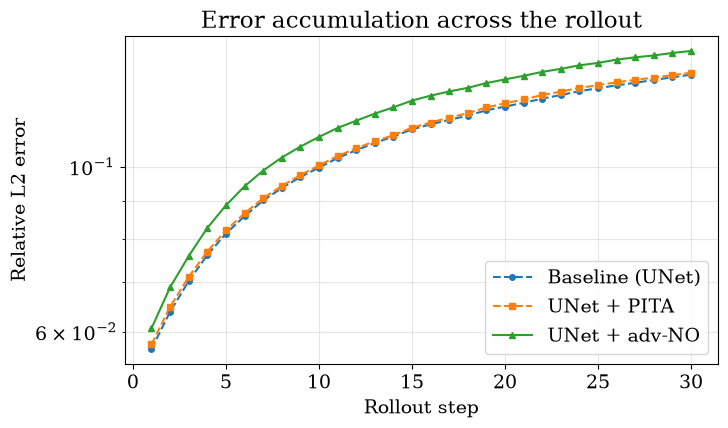

Baseline (UNet)     t=1: 0.0569   t=10: 0.0996   t=30: 0.1329
UNet + PITA         t=1: 0.0577   t=10: 0.1003   t=30: 0.1337
UNet + adv-NO       t=1: 0.0606   t=10: 0.1096   t=30: 0.1430


In [95]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
horizons = np.arange(1, ROLLOUT_T + 1)
err_curves = {}
for lab, pred in pred_L.items():
    e = get_u_diff_norm(act_L, pred, num_steps=ROLLOUT_T)
    err_curves[lab] = np.asarray(e)
    ax.plot(horizons, e, label=lab, markersize=4, **MODEL_STYLE[lab])
ax.set_yscale("log")
ax.set_xlabel("Rollout step")
ax.set_ylabel("Relative L2 error")
ax.set_title("Error accumulation across the rollout")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

for lab, e in err_curves.items():
    print(f"{lab:<18}  t=1: {e[0]:.4f}   t=10: {e[min(9, len(e)-1)]:.4f}   t={ROLLOUT_T}: {e[-1]:.4f}")

### Figure B: velocity-field snapshots

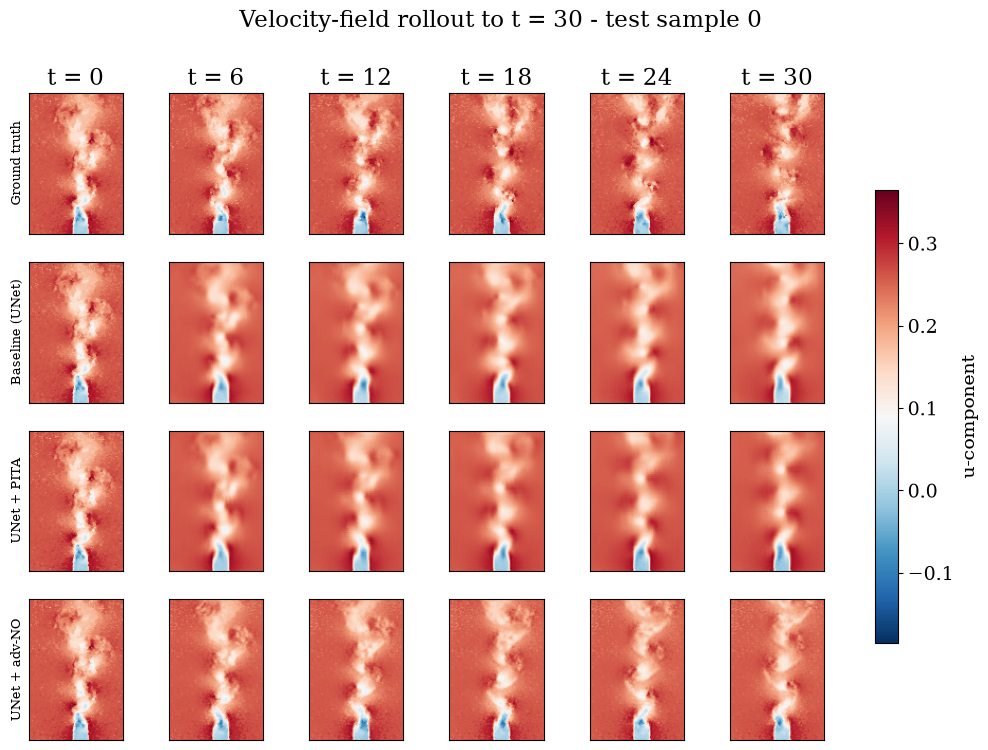

In [96]:
def plot_field_grid(rows, horizons, cmap, vmin, vmax, cbar_label, title):
    fig, axes = plt.subplots(len(rows), len(horizons),
                             figsize=(2.2 * len(horizons), 2.1 * len(rows)), squeeze=False)
    for r, (label, field) in enumerate(rows):
        for c, t in enumerate(horizons):
            ax = axes[r][c]
            im = ax.imshow(field[..., t], origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_xticks([])
            ax.set_yticks([])
            if r == 0: ax.set_title(f"t = {t}")
            if c == 0: ax.set_ylabel(label, fontsize=9)
    fig.colorbar(im, ax=axes, shrink=0.7, label=cbar_label)
    fig.suptitle(title)
    plt.show()

sample_idx = 0
component  = 0
horizons_L = list(range(0, ROLLOUT_T + 1, max(1, ROLLOUT_T // 5)))

rows = [("Ground truth", act_L[component, sample_idx])]
rows += [(lab, pred_L[lab][component, sample_idx]) for lab in pred_L]

gt_show = rows[0][1][..., horizons_L]
plot_field_grid(rows, horizons_L, cmap="RdBu_r",
                vmin=float(gt_show.min()), vmax=float(gt_show.max()),
                cbar_label="u-component",
                title=f"Velocity-field rollout to t = {ROLLOUT_T} - test sample {sample_idx}")

### Figure C: prediction error vs. ground truth

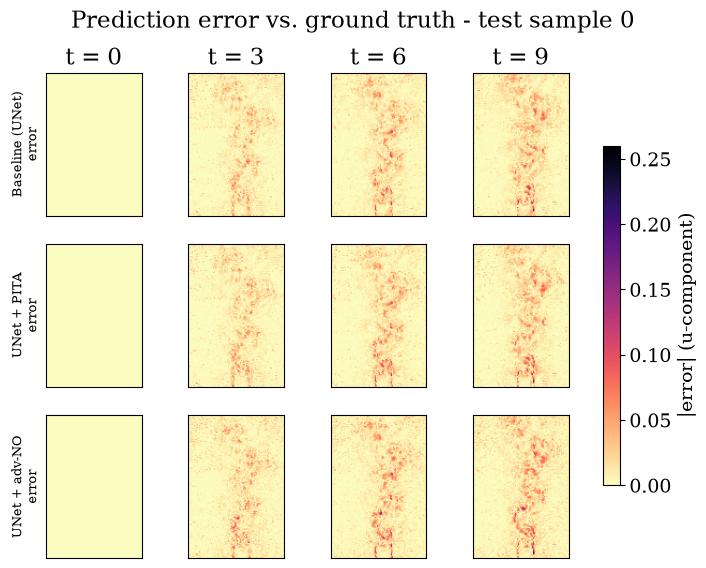

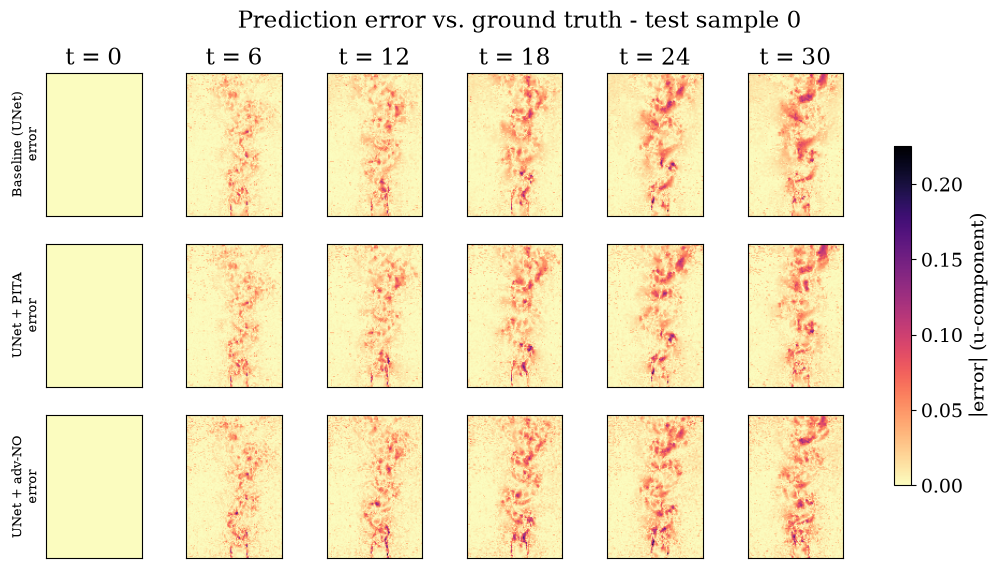

In [97]:
def plot_error_comparison(horizons, sample_idx=0, component=0):
    gt = act_L[component, sample_idx]
    rows = [(f"{lab}\nerror", np.abs(gt - pred_L[lab][component, sample_idx])) for lab in pred_L]
    vmax = max(float(field[..., horizons].max()) for _, field in rows)
    plot_field_grid(rows, horizons, cmap="magma_r", vmin=0, vmax=vmax,
                    cbar_label="|error| (u-component)",
                    title=f"Prediction error vs. ground truth - test sample {sample_idx}")

plot_error_comparison([0, 3, 6, 9])                # short horizon
plot_error_comparison(horizons_L)                  # full horizon, up to ROLLOUT_T

### Figure D: spectral bias, energy spectra

In [98]:
def energy_spectrum(field, nbins=40):
    # radially binned energy spectrum of one [H, W] field, k=0 bin dropped
    H, W = field.shape
    power = np.abs(np.fft.fft2(field))**2 / (H * W)

    ky = np.fft.fftfreq(H)
    kx = np.fft.fftfreq(W)
    KX, KY = np.meshgrid(kx, ky)
    k = np.sqrt(KX**2 + KY**2)

    bins = np.linspace(0, 0.5, nbins + 1)
    E_sum, edges = np.histogram(k, bins=bins, weights=power)
    counts, _    = np.histogram(k, bins=bins)
    E = E_sum / np.maximum(counts, 1)
    centers = 0.5 * (edges[1:] + edges[:-1])
    return centers[1:], E[1:]


def avg_spectrum(arr, t, n_samples=48):
    # spectrum averaged over samples and u, v
    Es = []
    n_samples = min(n_samples, arr.shape[1])
    for s in range(n_samples):
        for c in (0, 1):
            k, E = energy_spectrum(arr[c, s, :, :, t])
            Es.append(E)
    return k, np.mean(Es, axis=0)


# check
_k_test = np.sqrt(np.add.outer(np.fft.fftfreq(133)**2, np.fft.fftfreq(89)**2))
assert _k_test[0, 0] == 0.0
assert abs(_k_test.max() - 0.707) < 0.01

# truth vs truth at nearby times should be ~1
_k, _E0 = avg_spectrum(act_L, 0)
_,  _E5 = avg_spectrum(act_L, 5)
print(f"control: truth t0/t5 spectrum ratio, median = {np.median(_E0/_E5):.2f}")

control: truth t0/t5 spectrum ratio, median = 1.00


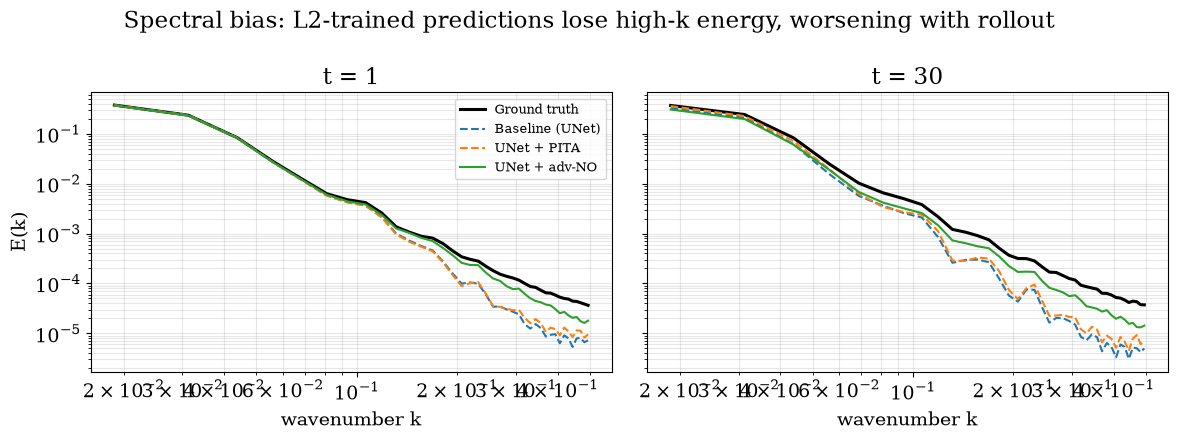

t= 1  energy ratio vs truth (1.00 = perfect)
       Baseline (UNet)    low-k: 0.97   high-k: 0.16
       UNet + PITA        low-k: 0.98   high-k: 0.23
       UNet + adv-NO      low-k: 0.98   high-k: 0.49
t=30  energy ratio vs truth (1.00 = perfect)
       Baseline (UNet)    low-k: 0.73   high-k: 0.10
       UNet + PITA        low-k: 0.83   high-k: 0.15
       UNet + adv-NO      low-k: 0.76   high-k: 0.38


In [99]:
# energy spectra, early and late
t_early, t_late = 1, ROLLOUT_T

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, t in zip(axes, (t_early, t_late)):
    k, E = avg_spectrum(act_L, t)
    ax.loglog(k, E, label="Ground truth", **TRUTH_STYLE)
    for lab, pred in pred_L.items():
        k, E = avg_spectrum(pred, t)
        st = MODEL_STYLE[lab]
        ax.loglog(k, E, color=st["color"], ls=st["ls"], label=lab)
    ax.set_title(f"t = {t}")
    ax.set_xlabel("wavenumber k")
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xticks([0.02, 0.05, 0.1, 0.2, 0.4], ["0.02", "0.05", "0.1", "0.2", "0.4"])
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
axes[0].set_ylabel("E(k)")
axes[0].legend(fontsize=9)
fig.suptitle("Energy spectra")
plt.tight_layout()
plt.show()

for t in (t_early, t_late):
    _, Ea = avg_spectrum(act_L, t)
    print(f"t={t:2d}  energy ratio vs truth (1.00 = perfect)")
    for lab, pred in pred_L.items():
        _, Ep = avg_spectrum(pred, t)
        print(f"       {lab:<18} low-k: {np.mean(Ep[:5]/Ea[:5]):.2f}   high-k: {np.mean(Ep[-10:]/Ea[-10:]):.2f}")